# Retinal Vessel Segmentation

**Group:**
* Jakub Biernat 160248
* Eryk Masian 160228

**Technologies Used:**
* **Language:** Python
* **Libraries:** TODO

## Imports

In [1]:
#General imports
from skimage import io
import ipywidgets as widgets
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
import numpy as np
from sklearn.metrics import confusion_matrix, accuracy_score
from imblearn.metrics import geometric_mean_score, specificity_score, sensitivity_score

#Imports for Retinal Vessel Detection via Image Processing
from skimage.filters import threshold_otsu, gaussian, sobel
from skimage.morphology import opening, closing
from skimage.color import rgb2gray
from skimage import exposure

#Imports for Retinal Vessel Detection via Traditional Machine Learning
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, balanced_accuracy_score
from numpy.lib.stride_tricks import sliding_window_view

#Imports for Retinal Vessel Detection via Deep Learning
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from skimage.transform import resize

## Images
From HRF image database: https://www5.cs.fau.de/research/data/fundus-images/

In [2]:
image_names = [f"{str(i).zfill(2)}_{suffix}" for i in range(1, 16) for suffix in ["h", "g", "dr"]]

def load_images(image_name):
    raw_image = io.imread(f"../data/images/{image_name}.jpg")
    gs_image = io.imread(f"../data/goldstandard/{image_name}.tif")
    mask = io.imread(f"../data/fovs/{image_name}_mask.tif")
    mask = mask[..., 0]
    return raw_image, gs_image, mask


## Quality metrics and visualisation

In [3]:
def generate_overlay(raw_image, mask_image):
    pred = mask_image > 0

    overlay = raw_image.copy()
    overlay[pred] = [0, 255, 0]

    return overlay

def calculate_metrics(gs_image, generated_image, mask = None):
    valid = mask > 0

    y_true = (gs_image > 0)[valid].astype(int)
    y_generated = (generated_image > 0)[valid].astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, y_generated, labels=[0, 1]).ravel()

    accuracy = accuracy_score(y_true, y_generated)

    sensitivity = sensitivity_score(y_true, y_generated)

    specificity = specificity_score(y_true, y_generated)

    gmean = geometric_mean_score(y_true, y_generated, average='binary')

    return {
        "TP": tp,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "Accuracy": accuracy,
        "Sensitivity": sensitivity,
        "Specificity": specificity,
        "G-Mean": gmean
    }

def print_average_metrics(metrics_per_image):
    mean_accuracy = np.mean([m["Accuracy"] for _, m in metrics_per_image])
    mean_sensitivity = np.mean([m["Sensitivity"] for _, m in metrics_per_image])
    mean_specificity = np.mean([m["Specificity"] for _, m in metrics_per_image])
    mean_gmean = np.mean([m["G-Mean"] for _, m in metrics_per_image])

    total_tp = sum(m["TP"] for _, m in metrics_per_image)
    total_tn = sum(m["TN"] for _, m in metrics_per_image)
    total_fp = sum(m["FP"] for _, m in metrics_per_image)
    total_fn = sum(m["FN"] for _, m in metrics_per_image)

    print("Średnie metryki na obrazach testowych:")
    print()
    print(f"{'Accuracy':12s}: {mean_accuracy:.4f}")
    print(f"{'Sensitivity':12s}: {mean_sensitivity:.4f}")
    print(f"{'Specificity':12s}: {mean_specificity:.4f}")
    print(f"{'G-Mean':12s}: {mean_gmean:.4f}")
    print()
    print("Suma wartości macierzy pomyłek:")
    print(f"{'TP':12s}: {total_tp}")
    print(f"{'TN':12s}: {total_tn}")
    print(f"{'FP':12s}: {total_fp}")
    print(f"{'FN':12s}: {total_fn}")

## Retinal Vessel Detection Functions

### Retinal Vessel Detection via Image processing

In [4]:
def retinal_vessel_segmentation_image_processing(image, mask):
    ######## Pre-processing ########
    image = rgb2gray(image)

    image = gaussian(image, sigma=1)

    image = exposure.equalize_hist(image)

    ######## Core processing ########
    image = sobel(image)

    ######## FOV only ########
    valid = mask > 0

    image_fov = image[valid]

    threshold = threshold_otsu(image_fov)

    ######## Post-processing ########
    generated_image = image > threshold

    generated_image[~valid] = False

    generated_image = closing(generated_image)
    generated_image = opening(generated_image)

    generated_image[~valid] = False

    return generated_image

### Retinal Vessel Detection via Traditional Machine Learning

In [5]:
def retinal_vessel_segmentation_machine_learning(
    image,
    mask,
    classifier,
    patch_size=5,
    batch_size=50000
):
    # Ten sam preprocessing co przy treningu
    green = image[:, :, 1].astype(np.float32)

    if green.max() > 1:
        green = green / 255.0

    green = exposure.equalize_adapthist(
        green,
        clip_limit=0.03
    ).astype(np.float32)

    h, w = green.shape
    half = patch_size // 2

    # Maska poprawnych pikseli
    if mask is None:
        valid = np.ones((h, w), dtype=bool)
    else:
        valid = mask > 0

    valid = valid.copy()

    # Usuwamy brzegi, żeby patch nie wychodził poza obraz
    valid[:half, :] = False
    valid[-half:, :] = False
    valid[:, :half] = False
    valid[:, -half:] = False

    ys, xs = np.where(valid)

    result = np.zeros((h, w), dtype=np.uint8)

    # Wszystkie możliwe patche jako "widok", bez ręcznego wycinania w pętli
    windows = sliding_window_view(green, (patch_size, patch_size))

    for start in range(0, len(ys), batch_size):
        end = start + batch_size

        yy = ys[start:end]
        xx = xs[start:end]

        patches = windows[
            yy - half,
            xx - half
        ]

        # Cechy muszą być w tej samej kolejności co przy treningu
        X = np.column_stack([
            np.mean(patches, axis=(1, 2)),
            np.var(patches, axis=(1, 2)),
            np.min(patches, axis=(1, 2)),
            np.max(patches, axis=(1, 2)),
            patches[:, half, half],
            np.std(patches, axis=(1, 2))
        ]).astype(np.float32)

        pred = classifier.predict(X)

        result[yy, xx] = pred.astype(np.uint8)

    if mask is not None:
        result[mask <= 0] = 0

    return result

def extract_patch_features(patch):
    half = patch.shape[0] // 2

    features = [
        np.mean(patch),
        np.var(patch),
        np.min(patch),
        np.max(patch),
        patch[half, half],
        np.std(patch)
    ]

    return features

def extract_features_from_image(
    image,
    gs_image,
    mask,
    samples_per_image=4000,
    patch_size=5,
    random_state=42
):
    ######## Pre-processing ########
    green = image[:, :, 1]
    green = green.astype(np.float32)

    if green.max() > 1:
        green = green / 255.0

    green = exposure.equalize_adapthist(
        green,
        clip_limit=0.03
    )

    #Patch extracting
    rng = np.random.default_rng(random_state)
    h, w = green.shape
    half = patch_size // 2

    expert = gs_image > 0

    valid = mask > 0

    #Cut out edges
    valid[:half, :] = False
    valid[-half:, :] = False
    valid[:, :half] = False
    valid[:, -half:] = False

    vessel_pixels = valid & expert
    background_pixels = valid & ~expert

    v_y, v_x = np.where(vessel_pixels)
    b_y, b_x = np.where(background_pixels)

    #Undersampling 50:50
    n_samples = min(
        samples_per_image // 2,
        len(v_y),
        len(b_y)
    )

    idx_v = rng.choice(len(v_y), n_samples, replace=False)
    idx_b = rng.choice(len(b_y), n_samples, replace=False)

    #Create labels
    selected_y = np.concatenate([
        v_y[idx_v],
        b_y[idx_b]
    ])

    selected_x = np.concatenate([
        v_x[idx_v],
        b_x[idx_b]
    ])

    labels = np.concatenate([
        np.ones(n_samples),
        np.zeros(n_samples)
    ])

    #Extracting features for each pixel
    features = []

    for y, x in zip(selected_y, selected_x):
        patch = green[
            y - half : y + half + 1,
            x - half : x + half + 1
        ]

        features.append(extract_patch_features(patch))

    X = np.array(features, dtype=np.float32)
    y = labels.astype(int)

    #Shuffling
    permutation = rng.permutation(len(y))

    X = X[permutation]
    y = y[permutation]

    return X, y

def build_dataset_from_images(
    selected_image_names,
    samples_per_image=4000,
    patch_size=5,
    random_state=42
):
    X_all = []
    y_all = []

    for i, image_name in enumerate(selected_image_names):
        print(f"Przetwarzanie obrazu: {image_name}")
        raw_image, gs_image, mask = load_images(image_name)

        X_img, y_img = extract_features_from_image(
            raw_image,
            gs_image,
            mask,
            samples_per_image=samples_per_image,
            patch_size=patch_size,
            random_state=random_state + i
        )

        X_all.append(X_img)
        y_all.append(y_img)

    X_all = np.vstack(X_all)
    y_all = np.concatenate(y_all)

    return X_all, y_all

def train_random_forest_retinal_classifier(
    train_image_names,
    test_image_names=None,
    samples_per_image=4000,
    patch_size=5,
    random_state=42
):
    #Dataset from train images
    X, y = build_dataset_from_images(
        selected_image_names=train_image_names,
        samples_per_image=samples_per_image,
        patch_size=patch_size,
        random_state=random_state
    )

    #Train set
    if test_image_names is None:
        X_train, X_test, y_train, y_test = train_test_split(
            X,
            y,
            train_size=2/3,
            test_size=1/3,
            stratify=y,
            random_state=random_state
        )
    else:
        X_train = X
        y_train = y

        X_test, y_test = build_dataset_from_images(
            selected_image_names=test_image_names,
            samples_per_image=samples_per_image,
            patch_size=patch_size,
            random_state=random_state + 1000
        )

    #Classifier
    classifier = RandomForestClassifier(
        n_estimators=100,
        max_depth=12,
        random_state=random_state,
        n_jobs=-1
    )

    #Classifier training
    classifier.fit(X_train, y_train)

    print("Wytrenowano klasyfikator.")

    return classifier

### Retinal Vessel Detection via Deep Learning

In [6]:
def prepare_sample(image, gs_image, mask, input_size=(256, 256)):
    ######## Pre-processing ########
    image = image.astype(np.float32)

    if image.max() > 1:
        image = image / 255.0

    if image.ndim == 2:
        image = np.dstack([image, image, image])

    valid = mask > 0
    gs = gs_image > 0

    ######## FOV only ########
    image = image.copy()
    image[~valid] = 0

    ######## Resizing ########
    image_resized = resize(
        image,
        input_size,
        preserve_range=True,
        anti_aliasing=True
    ).astype(np.float32)

    gs_resized = resize(
        gs.astype(np.float32),
        input_size,
        order=0,
        preserve_range=True,
        anti_aliasing=False
    )

    fov_resized = resize(
        valid.astype(np.float32),
        input_size,
        order=0,
        preserve_range=True,
        anti_aliasing=False
    )

    gs_resized = gs_resized > 0.5
    fov_resized = fov_resized > 0.5

    gs_resized[~fov_resized] = 0

    y = gs_resized.astype(np.float32)
    y = np.expand_dims(y, axis=-1)

    return image_resized, y

def build_unet_dataset(selected_image_names, input_size=(256, 256)):
    x_all = []
    y_all = []

    for image_name in selected_image_names:
        print(f"Przetwarzanie obrazu: {image_name}")

        raw_image, gs_image, mask = load_images(image_name)

        x_img, y_img = prepare_sample(
            image=raw_image,
            gs_image=gs_image,
            mask=mask,
            input_size=input_size
        )

        x_all.append(x_img)
        y_all.append(y_img)

    x_all = np.array(x_all, dtype=np.float32)
    y_all = np.array(y_all, dtype=np.float32)

    return x_all, y_all

def conv_block(x, filters):
    x = layers.Conv2D(
        filters,
        kernel_size=3,
        padding="same",
        activation="relu"
    )(x)

    x = layers.Conv2D(
        filters,
        kernel_size=3,
        padding="same",
        activation="relu"
    )(x)

    return x


def build_unet(
    input_shape=(256, 256, 3)
):
    inputs = layers.Input(input_shape)

    # Encoder
    c1 = conv_block(inputs, 32)
    p1 = layers.MaxPooling2D((2, 2))(c1)

    c2 = conv_block(p1, 64)
    p2 = layers.MaxPooling2D((2, 2))(c2)

    c3 = conv_block(p2, 128)
    p3 = layers.MaxPooling2D((2, 2))(c3)

    c4 = conv_block(p3, 256)
    p4 = layers.MaxPooling2D((2, 2))(c4)

    # Bottleneck
    c5 = conv_block(p4, 512)

    # Decoder
    u6 = layers.Conv2DTranspose(256, 2, strides=2, padding="same")(c5)
    u6 = layers.Concatenate()([u6, c4])
    c6 = conv_block(u6, 256)

    u7 = layers.Conv2DTranspose(128, 2, strides=2, padding="same")(c6)
    u7 = layers.Concatenate()([u7, c3])
    c7 = conv_block(u7, 128)

    u8 = layers.Conv2DTranspose(64, 2, strides=2, padding="same")(c7)
    u8 = layers.Concatenate()([u8, c2])
    c8 = conv_block(u8, 64)

    u9 = layers.Conv2DTranspose(32, 2, strides=2, padding="same")(c8)
    u9 = layers.Concatenate()([u9, c1])
    c9 = conv_block(u9, 32)

    outputs = layers.Conv2D(
        1,
        kernel_size=1,
        activation="sigmoid"
    )(c9)

    model = models.Model(inputs, outputs)

    return model

def dice_coef(y_true, y_pred, smooth=1e-6):
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])

    intersection = tf.reduce_sum(y_true_f * y_pred_f)

    return (2.0 * intersection + smooth) / (
        tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth
    )


def dice_loss(y_true, y_pred):
    return 1.0 - dice_coef(y_true, y_pred)


def bce_dice_loss(y_true, y_pred):
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    return bce + dice_loss(y_true, y_pred)

def retinal_vessel_segmentation_unet(
    image,
    mask,
    model,
    input_size=(256, 256),
    threshold=0.5
):
    """
    Segmentuje naczynia za pomocą wytrenowanej sieci U-Net.

    Zwraca maskę uint8:
    0   - tło
    255 - naczynie
    """

    original_h, original_w = mask.shape

    img = image.astype(np.float32)

    if img.max() > 1:
        img = img / 255.0

    if img.ndim == 2:
        img = np.dstack([img, img, img])

    if img.shape[-1] == 4:
        img = img[:, :, :3]

    fov = mask > 0

    img = img.copy()
    img[~fov] = 0

    img_resized = resize(
        img,
        input_size,
        preserve_range=True,
        anti_aliasing=True
    ).astype(np.float32)

    pred = model.predict(
        np.expand_dims(img_resized, axis=0),
        verbose=0
    )[0, :, :, 0]

    pred_original_size = resize(
        pred,
        (original_h, original_w),
        preserve_range=True,
        anti_aliasing=True
    )

    generated_mask = pred_original_size > threshold
    generated_mask[~fov] = False

    generated_mask = generated_mask.astype(np.uint8) * 255

    return generated_mask

def evaluate_unet_classifier(
    model,
    test_image_names,
    input_size=(256, 256),
    threshold=0.5
):
    """
    Testuje U-Net na pełnych obrazach testowych.
    Do oceny używa calculate_metrics.
    """

    metrics_per_image = []

    for image_name in test_image_names:
        print(f"Testowanie obrazu U-Net: {image_name}")

        raw_image, gs_image, mask = load_images(image_name)

        generated_image_unet = retinal_vessel_segmentation_unet(
            image=raw_image,
            mask=mask,
            model=model,
            input_size=input_size,
            threshold=threshold
        )

        metrics = calculate_metrics(
            gs_image=gs_image,
            generated_image=generated_image_unet,
            mask=mask
        )

        metrics_per_image.append((image_name, metrics))

    print()
    print_average_metrics(metrics_per_image)

    return metrics_per_image

def train_unet_retinal_model(
    train_image_names,
    test_image_names,
    input_size=(256, 256),
    epochs=15,
    batch_size=2,
    threshold=0.5,
    random_state=42
):
    """
    Trenuje model U-Net i sprawdza go na zbiorze testowym hold-out.
    """

    tf.keras.utils.set_random_seed(random_state)

    print("Budowanie zbioru uczącego U-Net...")
    X_train, y_train = build_unet_dataset(
        selected_image_names=train_image_names,
        input_size=input_size
    )

    print()
    print("Budowanie zbioru testowego U-Net...")
    X_test, y_test = build_unet_dataset(
        selected_image_names=test_image_names,
        input_size=input_size
    )

    print()
    print("Kształt X_train:", X_train.shape)
    print("Kształt y_train:", y_train.shape)
    print("Kształt X_test :", X_test.shape)
    print("Kształt y_test :", y_test.shape)

    model = build_unet(
        input_shape=(input_size[0], input_size[1], 3)
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss=bce_dice_loss,
        metrics=[
            "accuracy",
            dice_coef
        ]
    )

    callbacks = [
        EarlyStopping(
            monitor="val_loss",
            patience=5,
            restore_best_weights=True
        ),
        ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=3,
            min_lr=1e-6
        )
    ]

    print()
    print("Rozpoczynam trenowanie U-Net...")

    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_test, y_test),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=callbacks
    )

    print()
    print("Zakończono trenowanie U-Net.")
    print("Model jest zapisany w zmiennej: unet_model")

    print()
    print("=" * 80)
    print("Ocena zdolności predykcyjnych U-Net na pełnych obrazach testowych")
    print("=" * 80)
    print()

    metrics_per_image = evaluate_unet_classifier(
        model=model,
        test_image_names=test_image_names,
        input_size=input_size,
        threshold=threshold
    )

    return model, history, metrics_per_image

In [7]:
unet_model, unet_history, unet_metrics_per_image = train_unet_retinal_model(
    train_image_names=["01_dr", "01_g"],
    test_image_names=["04_h"],
    input_size=(256, 256),
    epochs=5,
    batch_size=2,
    threshold=0.5,
    random_state=42
)

Budowanie zbioru uczącego U-Net...
Przygotowywanie obrazu dla U-Net: 01_dr
Przygotowywanie obrazu dla U-Net: 01_g

Budowanie zbioru testowego U-Net...
Przygotowywanie obrazu dla U-Net: 04_h

Kształt X_train: (2, 256, 256, 3)
Kształt y_train: (2, 256, 256, 1)
Kształt X_test : (1, 256, 256, 3)
Kształt y_test : (1, 256, 256, 1)

Rozpoczynam trenowanie U-Net...
Epoch 1/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step - accuracy: 0.0711 - dice_coef: 0.1047 - loss: 1.6004 - val_accuracy: 0.2163 - val_dice_coef: 0.1589 - val_loss: 1.5432 - learning_rate: 1.0000e-04
Epoch 2/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.1776 - dice_coef: 0.1046 - loss: 1.5978 - val_accuracy: 0.2219 - val_dice_coef: 0.1587 - val_loss: 1.5408 - learning_rate: 1.0000e-04
Epoch 3/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.1835 - dice_coef: 0.1045 - loss: 1.5952 - val_accuracy: 0.2278 - val_dice_coef: 0.1585 - val_loss: 1.5386 - learning_rate: 1.0000e-04
Epoch 4/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 

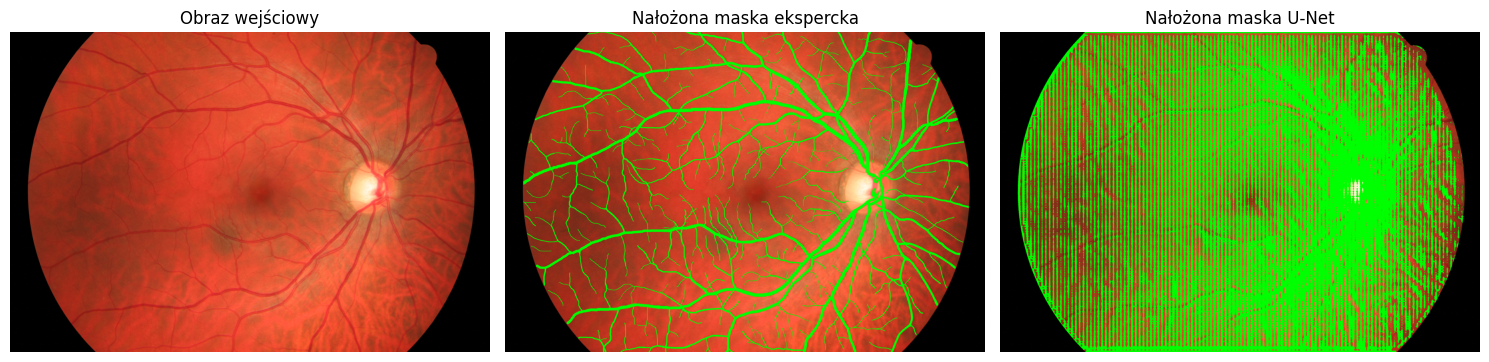

Metryki U-Net:
TP          : 540145
TN          : 2557785
FP          : 3522110
FN          : 293743
Accuracy    : 0.4481
Sensitivity : 0.6477
Specificity : 0.4207
G-Mean      : 0.5220


In [13]:
image_name = image_names[0]

raw_image, gs_image, mask = load_images(image_name)

generated_image_unet = retinal_vessel_segmentation_unet(
    image=raw_image,
    mask=mask,
    model=unet_model,
    input_size=(256, 256),
    threshold=0.5
)

unet_overlay = generate_overlay(raw_image, generated_image_unet)
gs_overlay = generate_overlay(raw_image, gs_image)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(raw_image)
axes[0].set_title("Obraz wejściowy")
axes[0].axis("off")

axes[1].imshow(gs_overlay)
axes[1].set_title("Nałożona maska ekspercka")
axes[1].axis("off")

axes[2].imshow(unet_overlay)
axes[2].set_title("Nałożona maska U-Net")
axes[2].axis("off")

plt.tight_layout()
plt.show()

metrics = calculate_metrics(
    gs_image=gs_image,
    generated_image=generated_image_unet,
    mask=mask
)

print("Metryki U-Net:")
for k, v in metrics.items():
    if isinstance(v, float):
        print(f"{k:12s}: {v:.4f}")
    else:
        print(f"{k:12s}: {v}")

## Training

### Functions

In [9]:
def split_image_names_into_sets(image_names, n_sets=5, random_state=42):
    rng = np.random.default_rng(random_state)
    shuffled_names = np.array(image_names)
    rng.shuffle(shuffled_names)

    image_sets = np.array_split(shuffled_names, n_sets)

    image_sets = [
        list(image_set)
        for image_set in image_sets
    ]

    return image_sets

def format_list_in_columns(items, columns=3):
    rows = []

    for i in range(0, len(items), columns):
        row_items = items[i:i + columns]

        cells = "".join([
            f"<td style='padding: 3px 15px 3px 0; font-family: monospace;'>{item}</td>"
            for item in row_items
        ])

        rows.append(f"<tr>{cells}</tr>")

    return "<table>" + "".join(rows) + "</table>"

### Training Machine Learning Classifier

In [10]:
ml_image_sets = split_image_names_into_sets(
    image_names,
    n_sets=5,
    random_state=42
)

test_set_selector = widgets.Dropdown(
    options=[
        (f"Zbiór testowy {i + 1} ({len(ml_image_sets[i])} obrazów)", i)
        for i in range(len(ml_image_sets))
    ],
    description="Test:"
)


samples_per_image_slider = widgets.IntSlider(
    value=5000,
    min=1000,
    max=15000,
    step=1000,
    description="Ilość próbek na obraz:",
    style={"description_width": "initial"},
    layout=widgets.Layout(width="350px")
)


train_ml_button = widgets.Button(
    description="Trenuj klasyfikator",
    button_style="success",
    icon="cogs"
)


ml_train_output = widgets.Output()

ml_sets_preview = widgets.HTML(
    value="",
    layout=widgets.Layout(
        border="1px solid #ddd",
        padding="10px",
        width="650px"
    )
)


def get_selected_train_test_sets():
    test_set_index = test_set_selector.value

    test_image_names = sorted(ml_image_sets[test_set_index])

    train_image_names = []

    for i, image_set in enumerate(ml_image_sets):
        if i != test_set_index:
            train_image_names.extend(image_set)

    train_image_names = sorted(train_image_names)

    return train_image_names, test_image_names, test_set_index

def show_selected_ml_sets(change=None):
    train_image_names, test_image_names, test_set_index = get_selected_train_test_sets()

    test_html = format_list_in_columns(
        test_image_names,
        columns=3
    )

    train_html = format_list_in_columns(
        train_image_names,
        columns=9
    )

    ml_sets_preview.value = f"""
    <h4>Wybrany zbiór testowy: {test_set_index + 1}</h4>

    <div style="display: flex; gap: 40px; align-items: flex-start;">

        <div>
            <b>Obrazy testowe ({len(test_image_names)}):</b>
            {test_html}
        </div>

        <div>
            <b>Obrazy treningowe ({len(train_image_names)}):</b>
            {train_html}
        </div>

    </div>
    """

def evaluate_classifier(
    classifier,
    test_image_names,
    patch_size=5
):
    metrics_per_image = []

    for image_name in test_image_names:
        print(f"Testowanie obrazu: {image_name}")

        raw_image, gs_image, mask = load_images(image_name)

        generated_image_ml = retinal_vessel_segmentation_machine_learning(
            image=raw_image,
            mask=mask,
            classifier=classifier,
            patch_size=patch_size
        )

        metrics = calculate_metrics(
            gs_image=gs_image,
            generated_image=generated_image_ml,
            mask=mask
        )

        metrics_per_image.append((image_name, metrics))

    print()
    print_average_metrics(metrics_per_image)

    return metrics_per_image


def train_ml_classifier_from_selected_set(button):
    global ml_classifier
    global ml_metrics_per_image

    train_ml_button.disabled = True

    with ml_train_output:
        clear_output(wait=True)

        train_image_names, test_image_names, test_set_index = get_selected_train_test_sets()

        print("Rozpoczynam trenowanie klasyfikatora")
        print()

        ml_classifier = train_random_forest_retinal_classifier(
            train_image_names=train_image_names,
            test_image_names=test_image_names,
            samples_per_image=samples_per_image_slider.value,
            patch_size=5,
            random_state=42
        )

        print("=" * 80)
        print("Ocena zdolności predykcyjnych na obrazach testowych")
        print("=" * 80)
        print()

        ml_metrics_per_image = evaluate_classifier(
            classifier=ml_classifier,
            test_image_names=test_image_names,
            patch_size=5
        )

        print()

    train_ml_button.disabled = False


test_set_selector.observe(show_selected_ml_sets, names="value")
train_ml_button.on_click(train_ml_classifier_from_selected_set)


left_ml_panel = widgets.VBox([
    test_set_selector,
    samples_per_image_slider,
    train_ml_button
])

top_ml_panel = widgets.HBox(
    [
        left_ml_panel,
        ml_sets_preview
    ],
    layout=widgets.Layout(
        width="100%"
    )
)


display(
    widgets.VBox([
        widgets.HTML("<h3>Trenowanie klasyfikatora Random Forest</h3>"),
        top_ml_panel,
        ml_train_output
    ])
)


show_selected_ml_sets()

### Training Deep Learing

In [11]:
#TODO

## App

In [12]:
# ---------------- UI ----------------
image_selector = widgets.Dropdown(
    options=image_names,
    description="Obraz:"
)

segment_button = widgets.Button(
    description="Segmentacja",
    button_style="success",
    icon="play"
)

view_mode = widgets.ToggleButtons(
    options=[
        ("Maski", "masks"),
        ("Nałożenia", "overlays")
    ],
    description="Widok:"
)

preview_output = widgets.Output()
result_output = widgets.Output()
metrics_output = widgets.Output()

last_result = {}

progress_bar = widgets.IntProgress(
    value=0,
    min=0,
    max=100,
    description="Postęp:",
    bar_style="",
    layout=widgets.Layout(width="250px", visibility="hidden")
)

progress_label = widgets.HTML(
    value="",
    layout=widgets.Layout(visibility="hidden")
)


# ---------------- CLEANING ----------------
def on_image_change(change):
    global last_result
    last_result = {}

    with preview_output:
        clear_output(wait=True)
    with result_output:
        clear_output(wait=True)
    with metrics_output:
        clear_output(wait=True)

    show_preview()


# ---------------- PREVIEW ----------------
def show_preview(change=None):
    with preview_output:
        clear_output(wait=True)

        image_name = image_selector.value
        raw_image, _, _ = load_images(image_name)

        plt.figure(figsize=(5, 5))
        plt.imshow(raw_image)
        plt.title(image_name)
        plt.axis("off")
        plt.show()


# ---------------- RESULT RENDERING ----------------
def render_result():
    if not last_result:
        return

    raw_image = last_result["raw_image"]
    gs_image = last_result["gs_image"]

    generated_image_ip = last_result["generated_image_ip"]
    generated_image_rf = last_result["generated_image_rf"]

    gs_overlay = last_result["gs_overlay"]
    generated_overlay_ip = last_result["generated_overlay_ip"]
    generated_overlay_rf = last_result["generated_overlay_rf"]

    with result_output:
        clear_output(wait=True)

        fig, axes = plt.subplots(1, 4, figsize=(20, 5))

        if view_mode.value == "masks":
            axes[0].imshow(raw_image)
            axes[0].set_title("Obraz wejściowy")

            axes[1].imshow(gs_image, cmap="gray")
            axes[1].set_title("Maska ekspercka")

            axes[2].imshow(generated_image_ip, cmap="gray")
            axes[2].set_title("Wygenerowana maska\nImage Processing")

            axes[3].imshow(generated_image_rf, cmap="gray")
            axes[3].set_title("Wygenerowana maska\nRandom Forest")

        elif view_mode.value == "overlays":
            axes[0].imshow(raw_image)
            axes[0].set_title("Obraz wejściowy")

            axes[1].imshow(gs_overlay)
            axes[1].set_title("Nałożona maska ekspercka")

            axes[2].imshow(generated_overlay_ip)
            axes[2].set_title("Nałożona maska\nImage Processing")

            axes[3].imshow(generated_overlay_rf)
            axes[3].set_title("Nałożona maska\nRandom Forest")

        for ax in axes:
            ax.axis("off")

        plt.tight_layout()
        plt.show()


# ---------------- METRICS PRINTING ----------------
def print_metrics(name, metrics):
    print(name)
    print("-" * len(name))

    for k, v in metrics.items():
        if isinstance(v, float):
            print(f"{k:12s}: {v:.4f}")
        else:
            print(f"{k:12s}: {v}")

    print()


# ---------------- SEGMENTATION ----------------
def run_segmentation(button):
    global last_result

    segment_button.disabled = True

    progress_bar.layout.visibility = "visible"
    progress_label.layout.visibility = "visible"

    progress_bar.value = 0
    progress_bar.bar_style = ""
    progress_label.value = "Przygotowywanie danych..."

    try:
        if "ml_classifier" not in globals():
            raise ValueError(
                "Najpierw wytrenuj klasyfikator Random Forest. "
                "Model powinien być zapisany w zmiennej ml_classifier."
            )

        image_name = image_selector.value

        progress_bar.value = 10
        progress_label.value = "Wczytywanie obrazu..."

        raw_image, gs_image, mask = load_images(image_name)

        progress_bar.value = 25
        progress_label.value = "Segmentacja metodą przetwarzania obrazu..."

        generated_image_ip = retinal_vessel_segmentation_image_processing(
            raw_image,
            mask
        )

        progress_bar.value = 50
        progress_label.value = "Segmentacja metodą Random Forest..."

        generated_image_rf = retinal_vessel_segmentation_machine_learning(
            image=raw_image,
            mask=mask,
            classifier=ml_classifier,
            patch_size=5
        )

        # Jeżeli funkcja ML zwraca wartości 0/1, zamieniamy na 0/255 dla czytelnego wyświetlania
        if generated_image_rf.max() == 1:
            generated_image_rf = generated_image_rf * 255

        progress_bar.value = 75
        progress_label.value = "Generowanie podglądu..."

        gs_overlay = generate_overlay(raw_image, gs_image)
        generated_overlay_ip = generate_overlay(raw_image, generated_image_ip)
        generated_overlay_rf = generate_overlay(raw_image, generated_image_rf)

        last_result = {
            "raw_image": raw_image,
            "gs_image": gs_image,
            "generated_image_ip": generated_image_ip,
            "generated_image_rf": generated_image_rf,
            "gs_overlay": gs_overlay,
            "generated_overlay_ip": generated_overlay_ip,
            "generated_overlay_rf": generated_overlay_rf
        }

        render_result()

        progress_bar.value = 90
        progress_label.value = "Obliczanie metryk..."

        metrics_ip = calculate_metrics(
            gs_image=gs_image,
            generated_image=generated_image_ip,
            mask=mask
        )

        metrics_rf = calculate_metrics(
            gs_image=gs_image,
            generated_image=generated_image_rf,
            mask=mask
        )

        with metrics_output:
            clear_output(wait=True)

            print("Metryki:")
            print()

            print_metrics(
                "Image Processing",
                metrics_ip
            )

            print_metrics(
                "Random Forest",
                metrics_rf
            )

        progress_bar.value = 100
        progress_bar.bar_style = "success"
        progress_label.value = "Segmentacja zakończona."

    except Exception as e:
        progress_bar.bar_style = "danger"
        progress_label.value = f"Błąd segmentacji: {e}"

    finally:
        segment_button.disabled = False


# ---------------- VIEW MODE CHANGE ----------------
def on_view_mode_change(change):
    render_result()


# ---------------- OBSERVERS ----------------
image_selector.observe(on_image_change, names="value")
view_mode.observe(on_view_mode_change, names="value")
segment_button.on_click(run_segmentation)


# ---------------- LAYOUT ----------------
left_panel = widgets.VBox([
    image_selector,
    view_mode,
    segment_button,
    progress_bar,
    progress_label
])

top_panel = widgets.HBox([
    left_panel,
    preview_output
])

display(
    widgets.VBox([
        top_panel,
        result_output,
        metrics_output
    ])
)

# pierwszy podgląd
show_preview()